# 01 · Reconstruction: the combined development index

The descriptive *past* layer of Amber. It takes the tidy panel the data layer wrote, scores every indicator against the pooled 7-country range, and aggregates the scores into three pillar sub-indices and one combined index.

This notebook is a walkthrough, not an implementation. Every step calls into `src/amber`, and `make index` produces the same table and charts from the command line.

**Prerequisite:** `make panel` (writes `data/processed/panel_interpolated.csv`).

In [1]:
%matplotlib inline
import logging

import pandas as pd

from amber import config, figures, reconstruction
from amber.modeling import index

logging.basicConfig(level=logging.WARNING)
pd.set_option("display.precision", 3)

panel = reconstruction.load_panel(
    config.PROCESSED_DATA_DIR / f"{config.PANEL_INTERPOLATED_STEM}.csv"
)
panel.shape

(1925, 9)

## 1 · Normalize

Each indicator is rescaled to [0, 1] by min-max, **pooled across every country-year from 2011 onward**. That keeps scores comparable across countries and over time. Three rules come from `config.py`:

- **Polarity:** poverty and under-5 mortality are lower-is-better, so they are inverted: `(max − x) / (max − min)`.
- **Log income:** GDP per capita is taken as `ln(x)` first, following the HDI. An extra dollar matters more at $1,000 per head than at $5,000.
- **Floor:** scores are clipped to [0.01, 1]. Without the floor, the worst country-year on any one indicator scores 0, and a geometric mean with a 0 in it is 0.

Missing values are dropped, not scored, so "missing" never gets confused with "worst".

In [2]:
normalized = index.normalize_indicators(panel)

(
    normalized.query("country_iso3 == 'MMR' and year == 2019")
    .assign(polarity=lambda d: d.indicator_id.map(config.INDICATOR_POLARITY).astype(str))[
        ["pillar", "indicator_id", "polarity", "value", "normalized"]
    ]
    .sort_values(["pillar", "indicator_id"])
)

,pillar,indicator_id,polarity,value,normalized
64,economy,BX.KLT.DINV.WD.GD.ZS,positive,2.312,0.196
353,economy,NY.GDP.MKTP.KD.ZG,positive,6.579,0.886
451,economy,NY.GDP.PCAP.KD,positive,1440.990,0.374
635,human_development,SH.DYN.MORT,negative,43.600,0.380
729,human_development,SH.XPD.CHEX.GD.ZS,positive,3.814,0.478
891,human_development,SP.DYN.LE00.IN,positive,66.457,0.225
161,innovation,IT.CEL.SETS.P2,positive,155.669,0.956
259,innovation,IT.NET.USER.ZS,positive,36.541,0.428
982,innovation,TX.VAL.TECH.MF.ZS,positive,2.751,0.060


## 2 · Pillars and the combined index

- **Pillar sub-index:** the geometric mean of the normalized indicators observed in that pillar for that country-year.
- **Combined index:** `exp(Σ wᵢ · ln pᵢ / Σ wᵢ)` across the three pillars. The weights are equal by default and renormalized, so any scale works.

A geometric mean stops a strong pillar from covering for a weak one. For the same reason, a country-year only gets a combined score when every weighted pillar is present.

In [3]:
idx = index.compute_index(panel)

idx.query("series == 'combined'").pivot(index="year", columns="country_name", values="value")

country_name,Bangladesh,Cambodia,Indonesia,Lao PDR,Myanmar,Nepal,Vietnam
year,,,,,,,
2011,0.134,0.183,0.291,0.165,0.048,0.127,0.653
2012,0.152,0.214,0.382,0.233,0.079,0.153,0.688
2013,0.180,0.260,0.385,0.284,0.103,0.169,0.691
2014,0.195,0.266,0.411,0.356,0.177,0.189,0.709
2015,0.213,0.284,0.441,0.403,0.227,0.197,0.739
2016,0.226,0.373,0.402,0.417,0.349,0.236,0.762
2017,0.232,0.378,0.497,0.466,0.389,0.293,0.787
2018,0.254,0.422,0.494,0.471,0.361,0.252,0.824
2019,0.388,0.414,0.526,0.460,0.343,0.314,0.822


## 3 · Coverage: read this before the charts

A pillar is computed over the indicators that are actually observed. `coverage` is the share observed. When coverage changes, the pillar is built from a different set of indicators, and part of any movement comes from that change rather than from development.

Myanmar's case matters most here:

- Poverty data exists only for 2015–2017.
- Secondary enrollment stops after 2018.
- Internet use stops after 2020.

The charts draw every partial-coverage point as a hollow ring.

In [4]:
idx.query("country_iso3 == 'MMR' and series != 'combined'").pivot(
    index="year", columns="series", values="coverage"
)

series,economy,human_development,innovation
year,,,
2011,0.75,1.00,1.000
2012,0.75,1.00,1.000
2013,0.75,1.00,1.000
2014,0.75,1.00,1.000
2015,1.00,1.00,1.000
2016,1.00,1.00,1.000
2017,1.00,1.00,1.000
2018,0.75,1.00,1.000
2019,0.75,0.75,1.000


## 4 · Charts

The same three figures `make index` writes to `reports/figures/`.

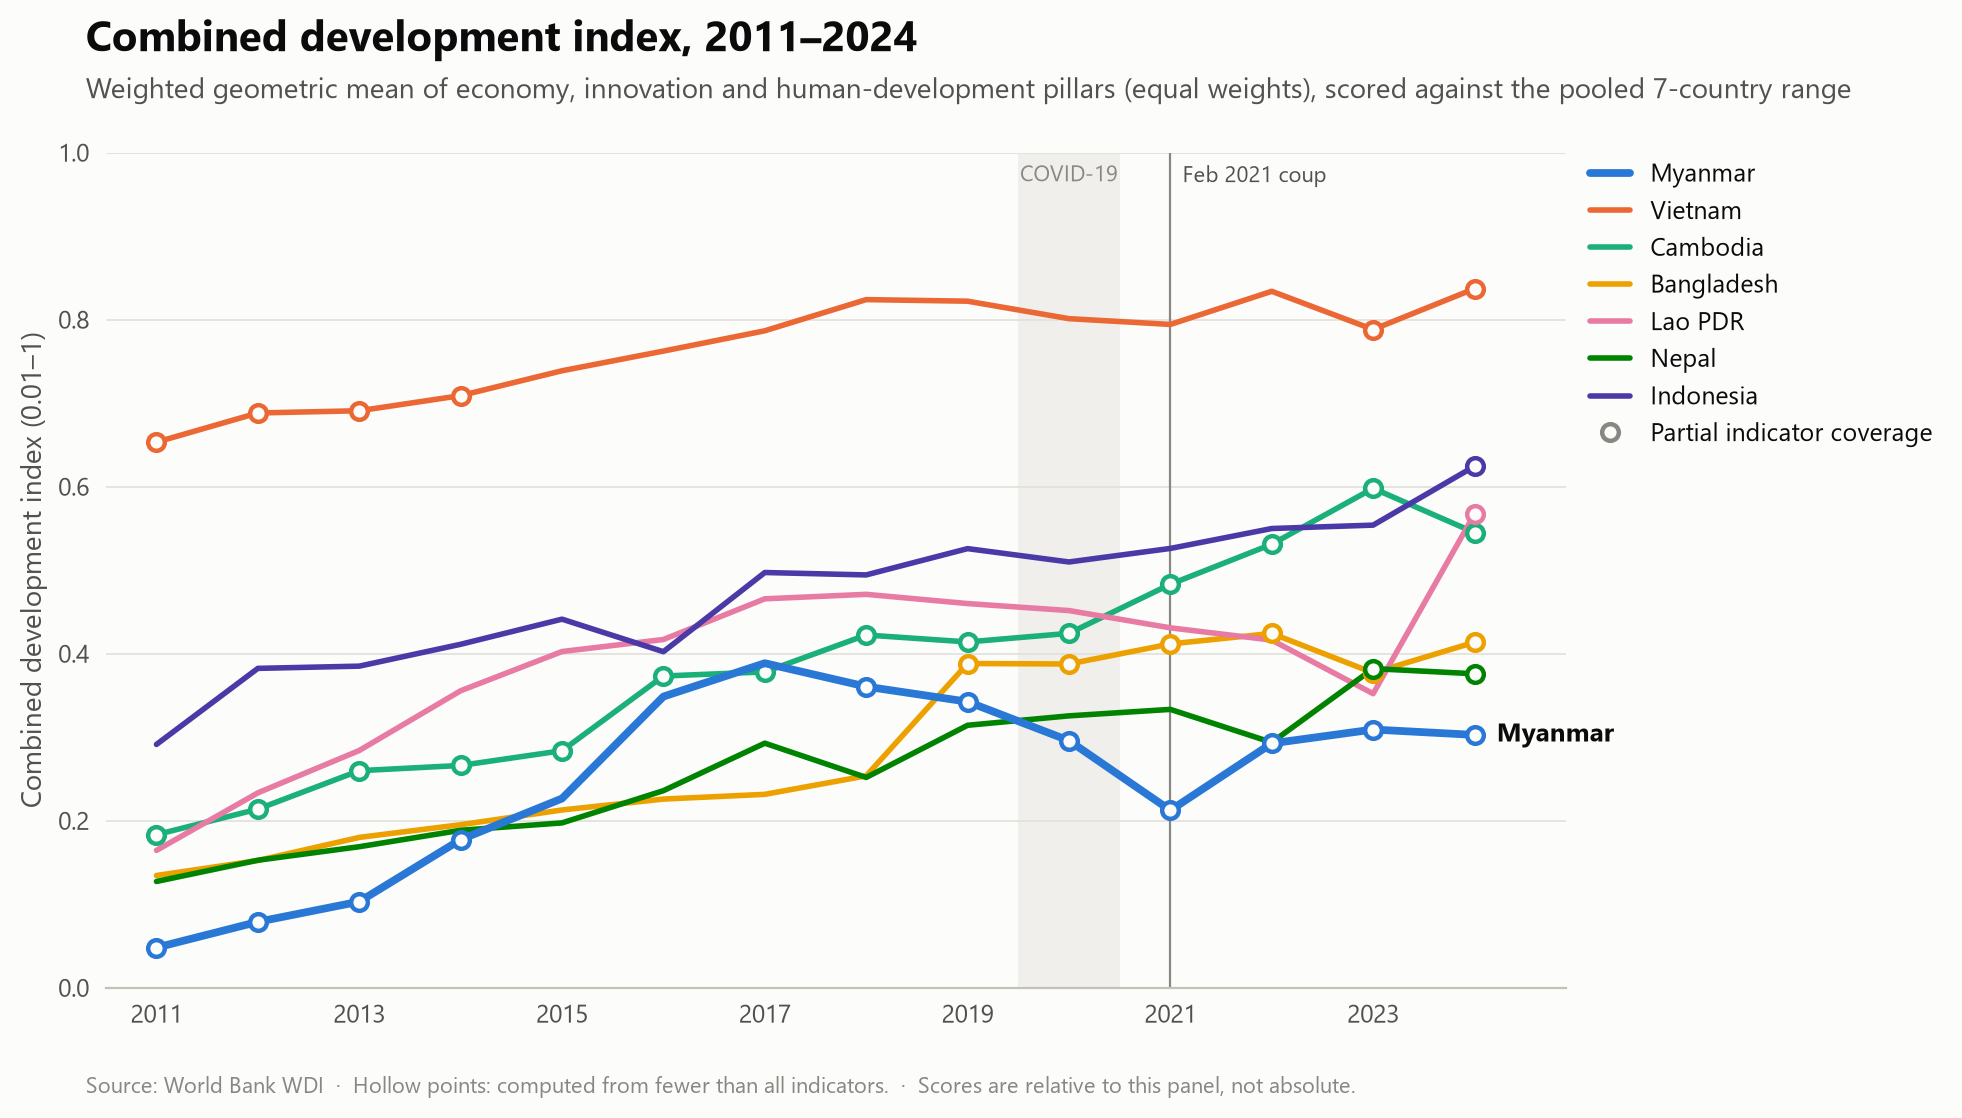

In [5]:
figures.combined_index_figure(idx)

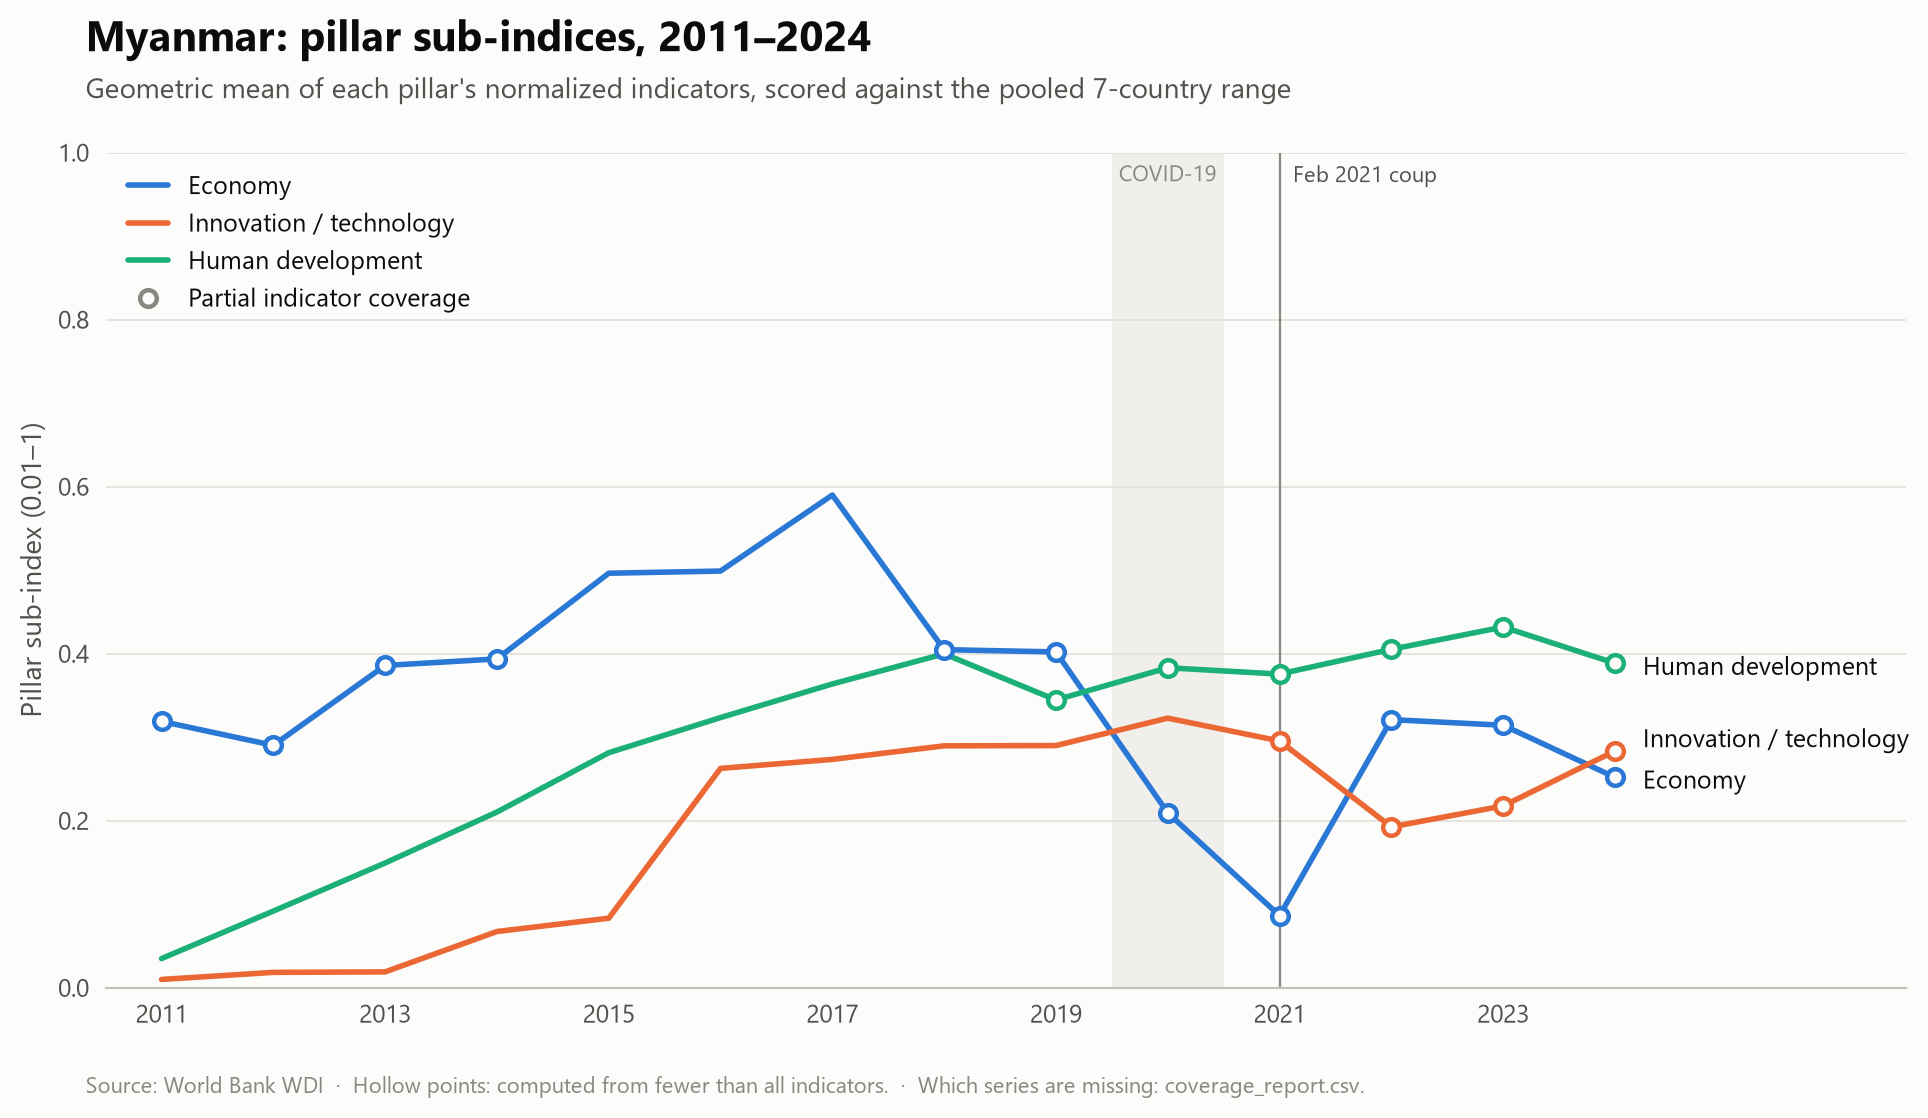

In [6]:
figures.myanmar_pillars_figure(idx)

Real GDP per capita, uncomposited. On a log scale, equal slopes mean equal growth rates. WDI reports Myanmar on its October–September fiscal year, so 2020 and 2021 do not line up with calendar-year IMF figures. That is a known difference between the two bases. It is not a data error.

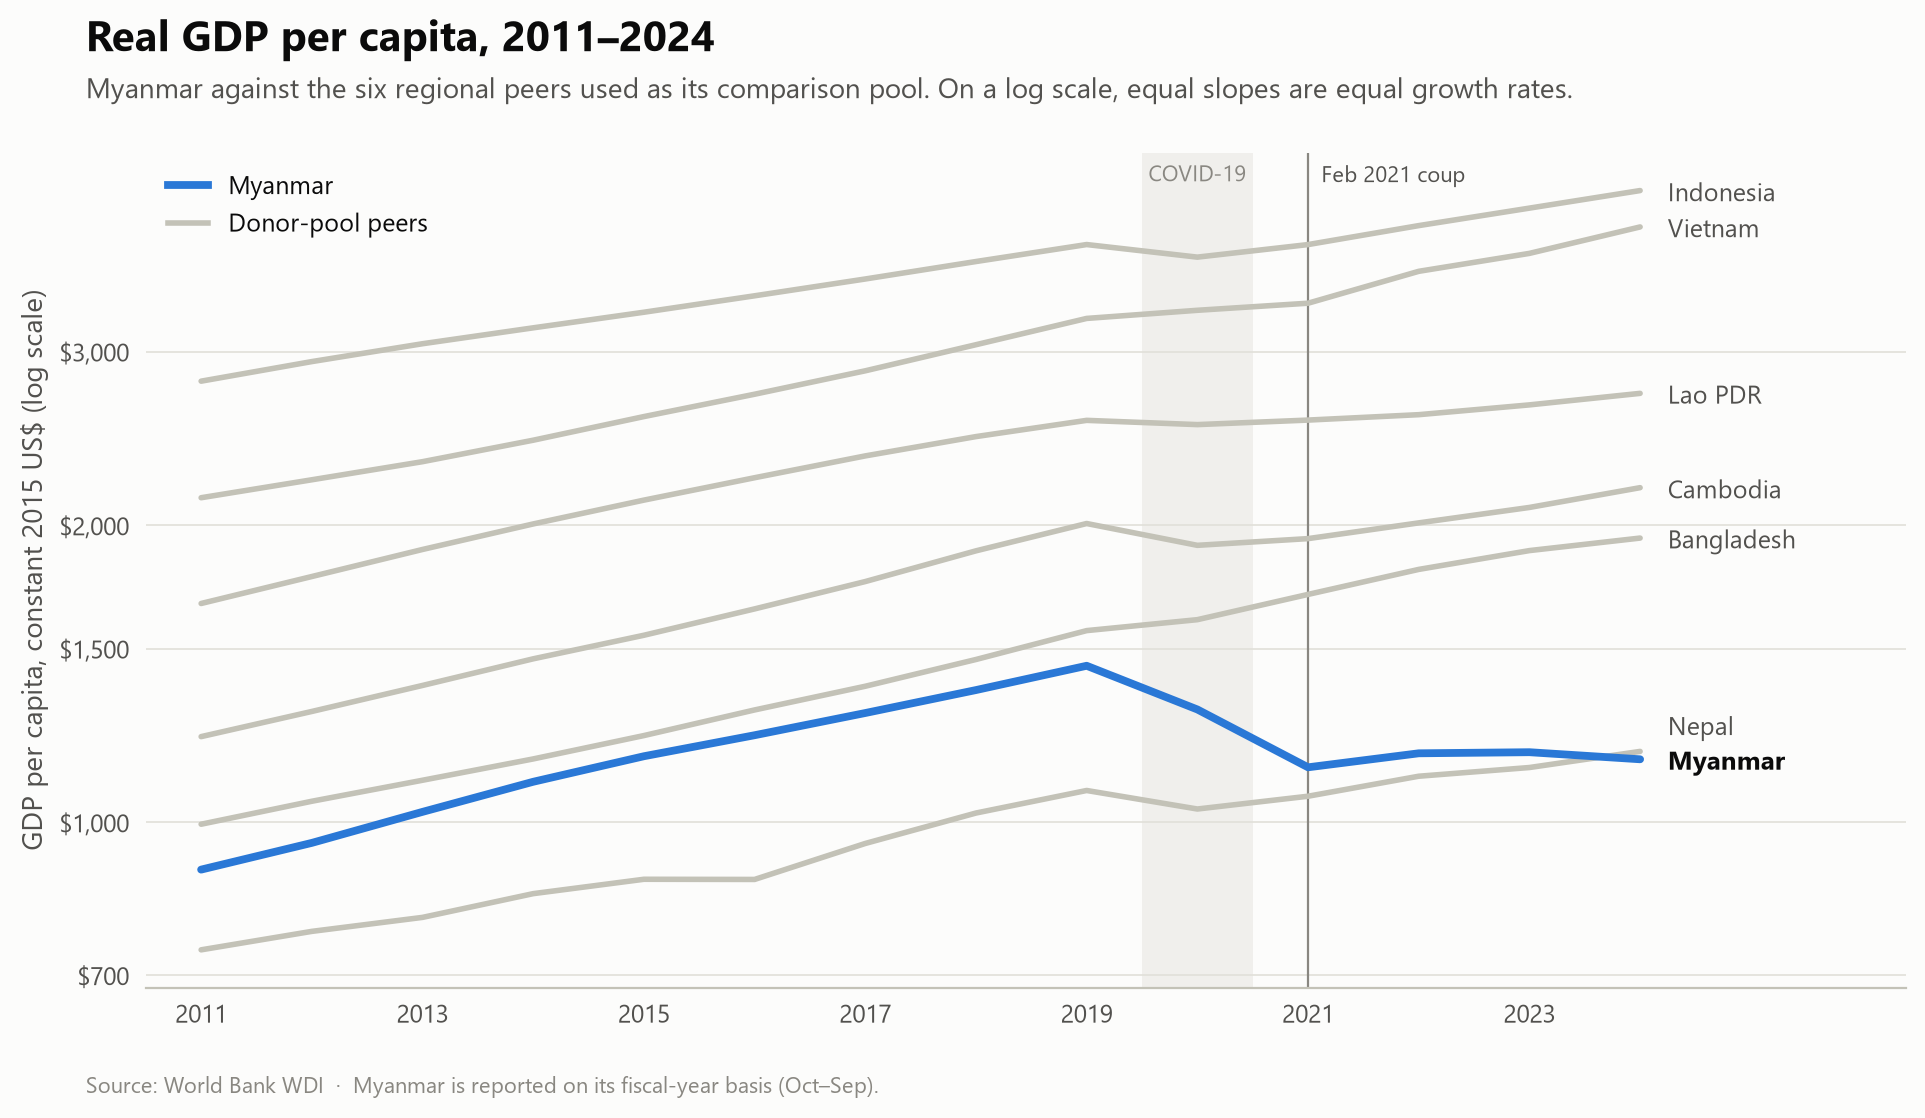

In [7]:
figures.gdp_pc_divergence_figure(panel)

## 5 · The weights are a setting

How development is defined is a choice. The same data under a different weighting:

In [8]:
weightings = {
    "equal": None,
    "economy-led": {"economy": 2, "innovation": 1, "human_development": 1},
    "people-led": {"economy": 1, "innovation": 1, "human_development": 2},
}

pd.DataFrame(
    {
        name: index.compute_index(panel, w)
        .query("series == 'combined' and year == 2019")
        .set_index("country_name")["value"]
        for name, w in weightings.items()
    }
).sort_values("equal", ascending=False)

,equal,economy-led,people-led
country_name,,,
Vietnam,0.822,0.804,0.831
Indonesia,0.526,0.534,0.546
Lao PDR,0.460,0.488,0.433
Cambodia,0.414,0.485,0.410
Bangladesh,0.388,0.367,0.393
Myanmar,0.343,0.357,0.343
Nepal,0.314,0.303,0.369
